In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

In [2]:
# DATA ANALYSIS
# Load the dataset
df = pd.read_csv('dataset-project.csv')
# Display the first few rows
print(df.head())
# Check data types
print(df.dtypes)

   Age   BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  \
0   24  34.7                       1                       25.2   
1   37  26.4                       0                       57.1   
2   32  23.6                       0                       92.7   
3   28  28.8                       0                       63.1   
4   25  22.1                       1                       59.8   

   Antral_Follicle_Count  PCOS_Diagnosis  
0                     20               0  
1                     25               0  
2                     28               0  
3                     26               0  
4                      8               0  
Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64
dtype: object


In [3]:
# Feature Engineering: Create Age Group and BMI Category
def categorize_age(age):
    if age < 20:
        return 'Teen'
    elif 20 <= age < 30:
        return 'Young Adult'
    elif 30 <= age < 40:
        return 'Adult'
    else:
        return 'Older Adult'

In [4]:

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'


In [5]:
# Apply the categorization functions
df['Age_Group'] = df['Age'].apply(categorize_age)
df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

# Display the first few rows of the updated DataFrame
print(df.head())

# Display the list of all columns to see the newly added features
print("Updated feature columns:")
print(df.columns)

# Convert categorical variables to numeric using one-hot encoding
df = pd.get_dummies(df, columns=['Age_Group', 'BMI_Category'], drop_first=True)


   Age   BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  \
0   24  34.7                       1                       25.2   
1   37  26.4                       0                       57.1   
2   32  23.6                       0                       92.7   
3   28  28.8                       0                       63.1   
4   25  22.1                       1                       59.8   

   Antral_Follicle_Count  PCOS_Diagnosis    Age_Group BMI_Category  
0                     20               0  Young Adult        Obese  
1                     25               0        Adult   Overweight  
2                     28               0        Adult       Normal  
3                     26               0  Young Adult   Overweight  
4                      8               0  Young Adult       Normal  
Updated feature columns:
Index(['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)',
       'Antral_Follicle_Count', 'PCOS_Diagnosis', 'Age_Group', 'BMI_Category'],
  

In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")
# Count Unique Values
print(df['PCOS_Diagnosis'].value_counts())

Number of duplicate records: 0
PCOS_Diagnosis
0    801
1    199
Name: count, dtype: int64


In [7]:
#
# VISUALIZATION
sns.set(style="whitegrid")

# List of features to visualize (excluding the target variable)
feats = df.columns.difference(['PCOS_Diagnosis'])


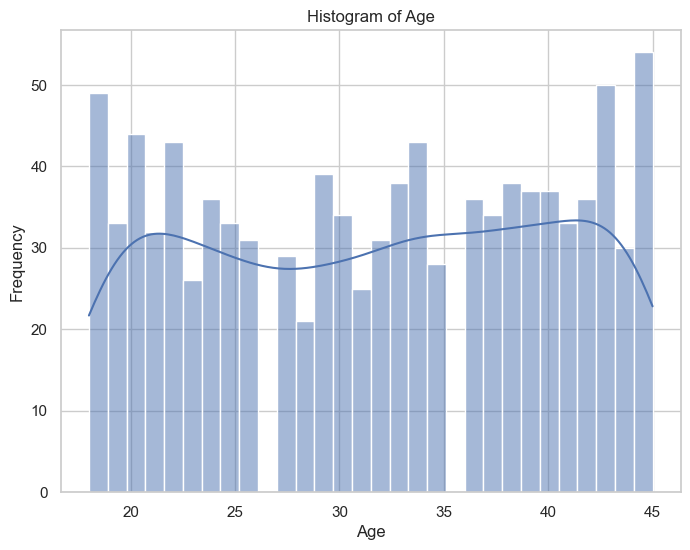

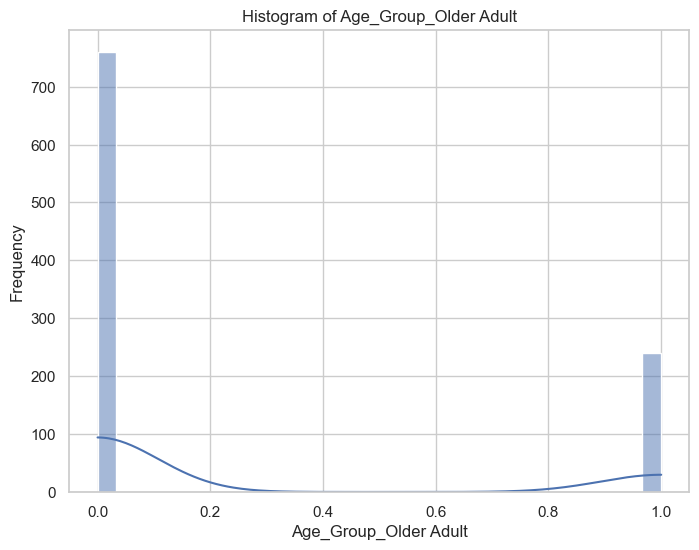

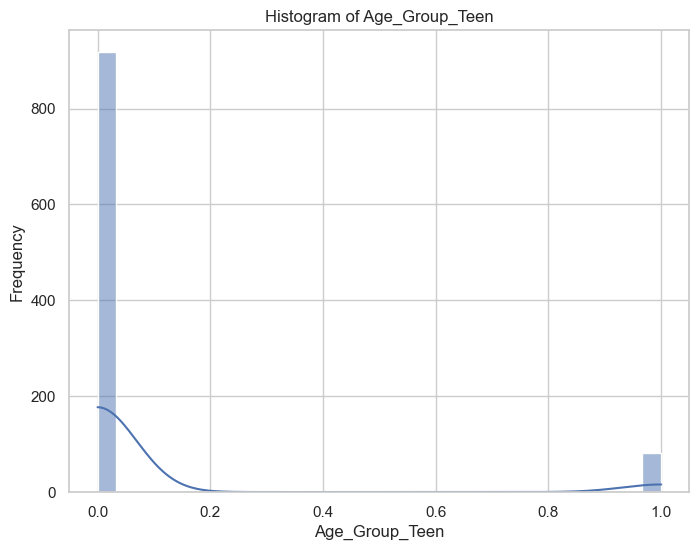

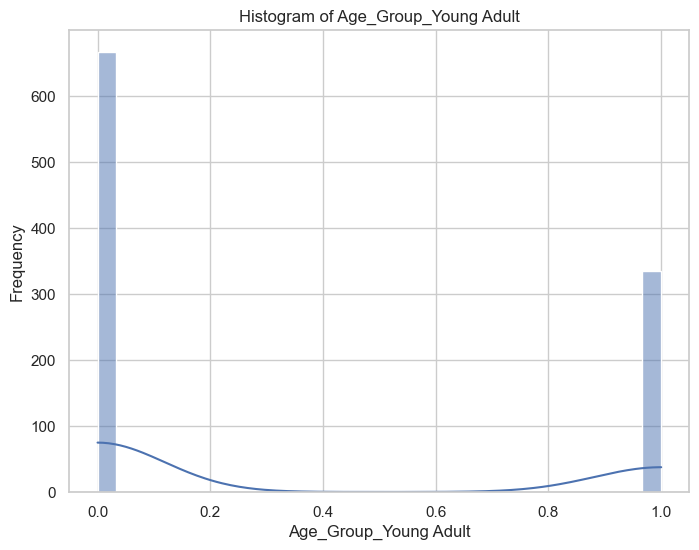

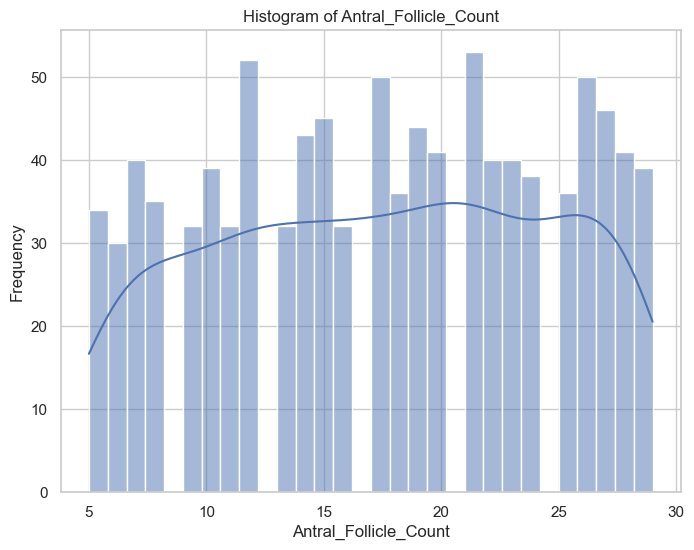

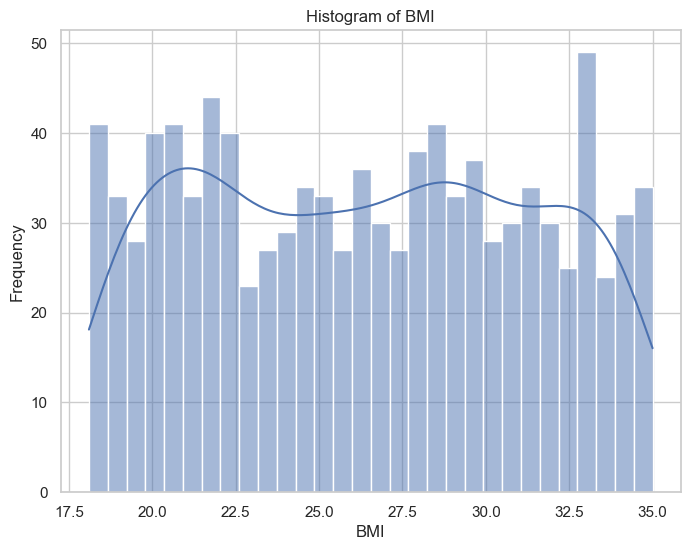

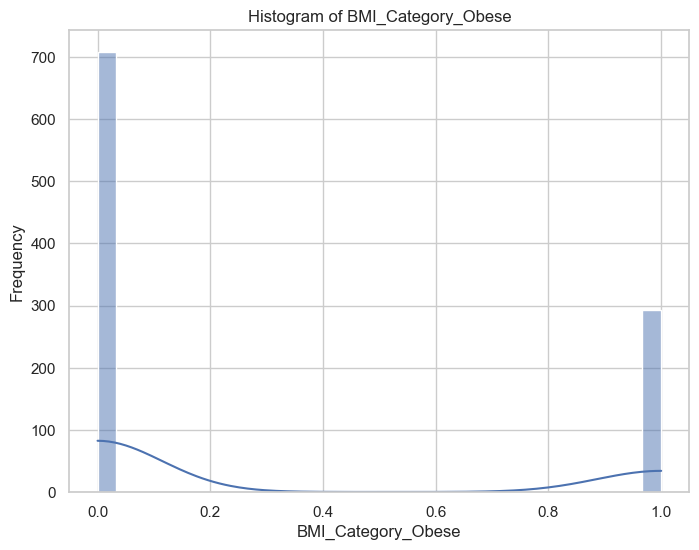

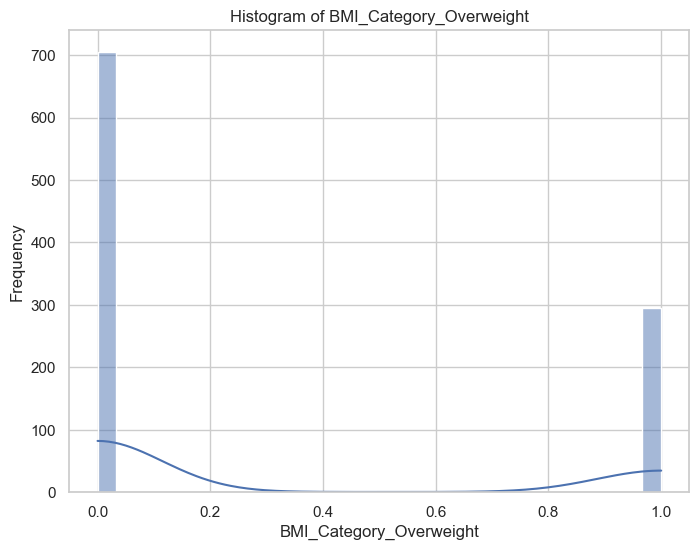

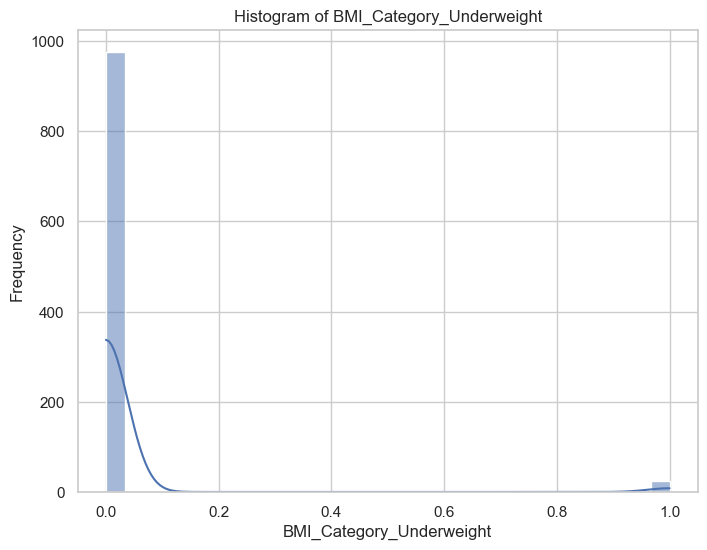

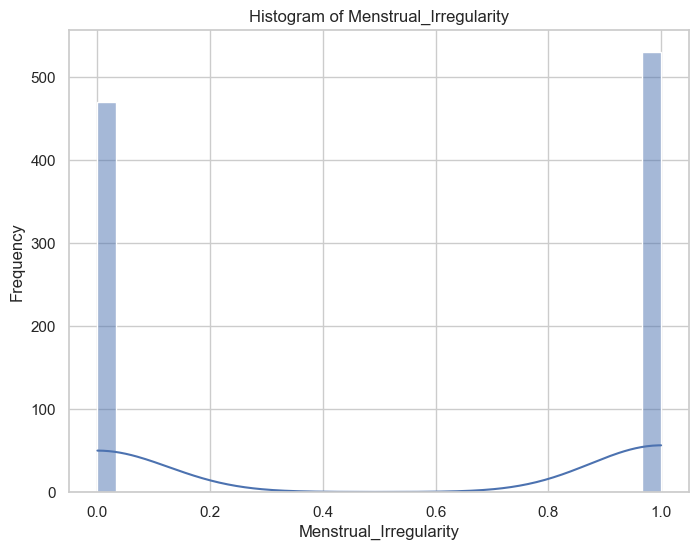

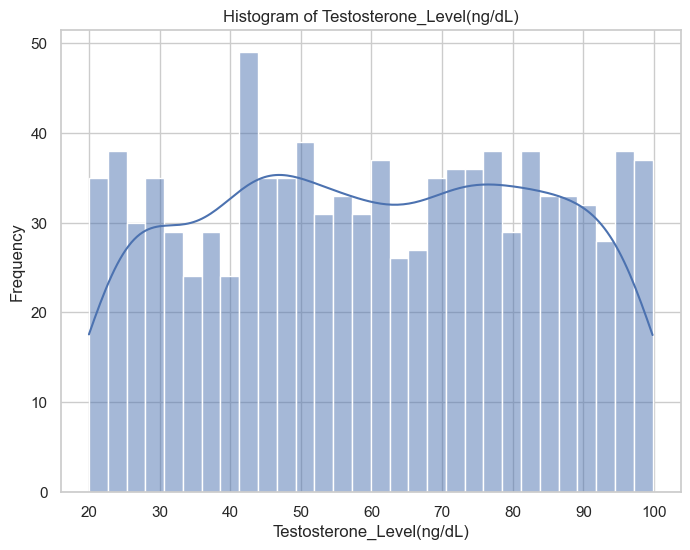

In [8]:
#
# Create histograms for each feature
for feature in feats:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [9]:
# Correlation Analysis
# Convert columns to numeric
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

                                Age       BMI  Menstrual_Irregularity  \
Age                        1.000000 -0.049455                0.032300   
BMI                       -0.049455  1.000000                0.031189   
Menstrual_Irregularity     0.032300  0.031189                1.000000   
Testosterone_Level(ng/dL) -0.050129  0.003811                0.042694   
Antral_Follicle_Count      0.017841  0.030724                0.035851   
PCOS_Diagnosis            -0.064675  0.377852                0.469376   
Age_Group_Older Adult      0.725189 -0.044702                0.017827   
Age_Group_Teen            -0.472323  0.027091               -0.047176   
Age_Group_Young Adult     -0.631253  0.020606               -0.012830   
BMI_Category_Obese        -0.065812  0.779809                0.027497   
BMI_Category_Overweight    0.025547  0.148080                0.016036   
BMI_Category_Underweight   0.005790 -0.257997                0.069122   

                           Testosterone_Level(ng/d

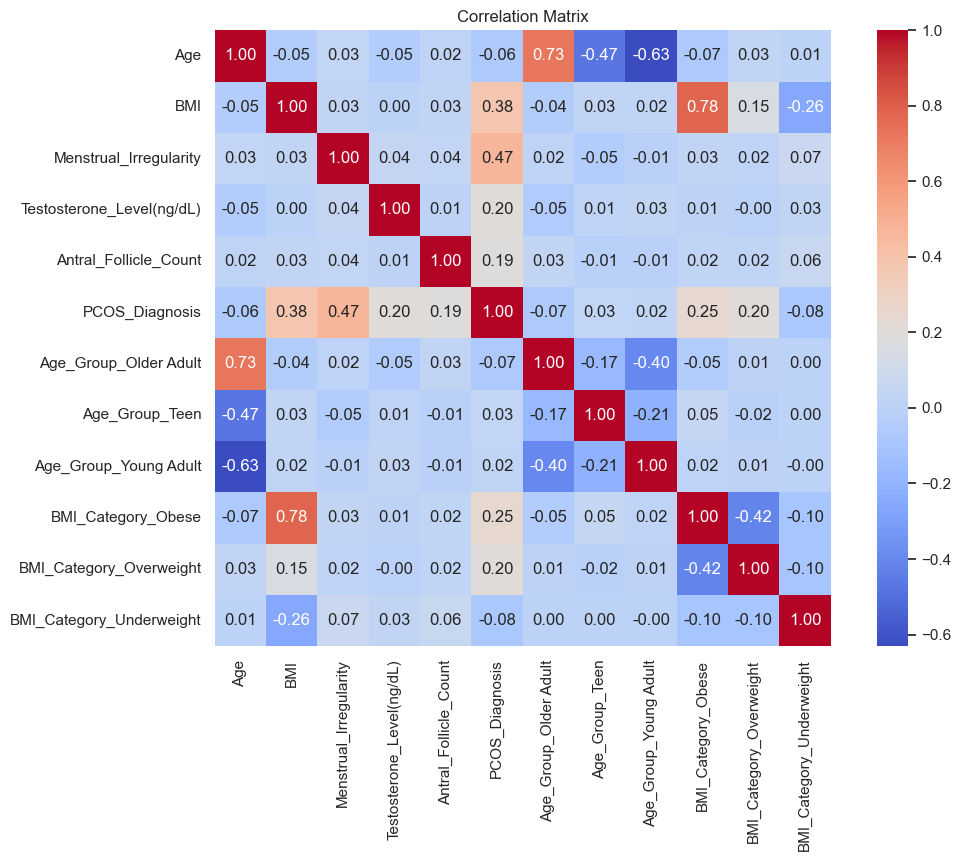

In [10]:
# Calculate the correlation matrix
corr_mat = df.corr()
print(corr_mat)
# Visualizing correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

In [11]:
# DATA PREPROCESSING - DATA CLEANING
# Check for missing values
missing_vals = df.isnull().sum()
print("Missing values in each column:", missing_vals)
# Forward fill missing values if necessary
df.ffill(inplace=True)

Missing values in each column: Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
Age_Group_Older Adult        0
Age_Group_Teen               0
Age_Group_Young Adult        0
BMI_Category_Obese           0
BMI_Category_Overweight      0
BMI_Category_Underweight     0
dtype: int64


In [12]:
# Prepare features and target variable
X = df.drop(['PCOS_Diagnosis'], axis=1)
Y = df['PCOS_Diagnosis']

# Data Splitting
# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Drop rows with missing values
X_train_clean = X_train.dropna()
Y_train_clean = Y_train[X_train.index.isin(X_train_clean.index)]


In [13]:
#  Model fitting
# RANDOM FOREST with RFE
RF_model = RandomForestClassifier()

# Initialize variables to track the best number of features
best_n_features = 0
best_accuracy = 0
# Test RFE for different numbers of features
for n_features in range(1, X.shape[1] + 1):
    rfe = RFE(estimator=RF_model, n_features_to_select=n_features)
    rfe.fit(X_train, Y_train)
    # Predict on the test set
    Y_predict = rfe.predict(X_test)
    # Calculate accuracy
    accuracy = accuracy_score(Y_test, Y_predict)
    # Update best features if the current accuracy is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_n_features = n_features
# Final RFE with the best number of features
final_rfe = RFE(estimator=RF_model, n_features_to_select=best_n_features)
final_rfe.fit(X_train, Y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestClassifier()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",4
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [14]:
# Get the selected features
sel_feats = X.columns[final_rfe.support_]
print("Best Number of Features:", best_n_features)
print("Best Accuracy:", best_accuracy)
print("Selected Features:")
print(sel_feats)
#
# Perform Grid Search on selected features
par_g = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
g_search = GridSearchCV(estimator=RF_model, param_grid=par_g, cv=5)
g_search.fit(X_train, Y_train)

Best Number of Features: 4
Best Accuracy: 0.995
Selected Features:
Index(['BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)',
       'Antral_Follicle_Count'],
      dtype='object')


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [15]:
# RANDOM FOREST
# Filter training and test sets to include only selected features
X_train = X_train[sel_feats]
X_test = X_test[sel_feats]

# Retrain model with selected features
RF_model.fit(X_train, Y_train)
# Perform Grid Search on selected feats for RF
par_RF = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
RF_search = GridSearchCV(estimator=RF_model, param_grid=par_RF, cv=5)
# Fitting Grid Search into the training data
RF_search.fit(X_train, Y_train)
print('Best Params for RF:', RF_search.best_params_)

Best Params for RF: {'max_depth': None, 'n_estimators': 50}


In [16]:
# Evaluation_RF
Y_predi = RF_model.predict(X_test)
print("Accuracy_RF:", accuracy_score(Y_test, Y_predi))
print("Confusion Matrix_RF:\n", confusion_matrix(Y_test, Y_predi))
print("Classification Report_RF:\n", classification_report(Y_test, Y_predi))


Accuracy_RF: 0.995
Confusion Matrix_RF:
 [[161   0]
 [  1  38]]
Classification Report_RF:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       161
           1       1.00      0.97      0.99        39

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [17]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No PCOS', 'PCOS'],
                yticklabels=['No PCOS', 'PCOS'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

Accuracy_RF: 0.995


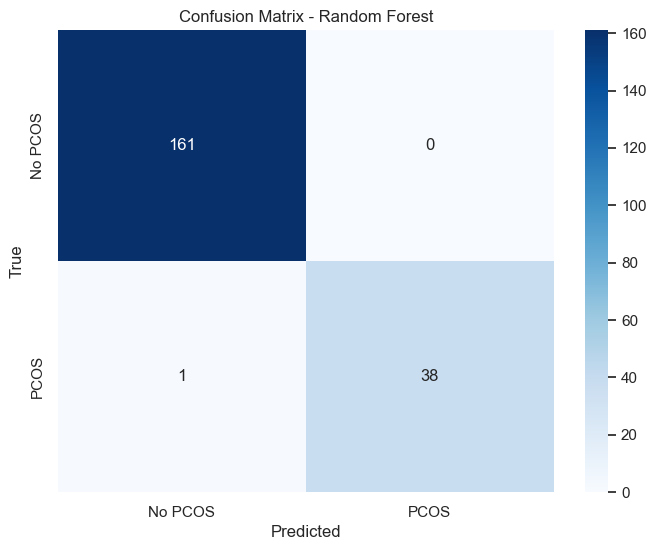

In [18]:
Y_predi = RF_model.predict(X_test)
print("Accuracy_RF:", accuracy_score(Y_test, Y_predi))
plot_confusion_matrix(Y_test, Y_predi, "Random Forest")

In [19]:
# SUPPORT VECTOR MACHINE
SVM_model = SVC(kernel='linear')

# Filter training and test sets to include only selected features
X_train = X_train[sel_feats]
X_test = X_test[sel_feats]

# Retrain model with selected features
SVM_model.fit(X_train, Y_train)

# Retrain model with selected feats
SVM_model.fit(X_train, Y_train)
# Perform Grid Search on selected feats for SVM
par_SVM = {'C': [0.1, 1, 10, 20]}
SVM_search = GridSearchCV(estimator=SVM_model, param_grid=par_SVM, cv=5)
# Fitting Grid Search into the training data
SVM_search.fit(X_train, Y_train)
print('Best Params for SVM:', SVM_search.best_params_)

Best Params for SVM: {'C': 1}


In [20]:
# Evaluation_SVM
Y_predi = SVM_model.predict(X_test)
print("Accuracy_SVM:", accuracy_score(Y_test, Y_predi))
print("Confusion Matrix_SVM:\n", confusion_matrix(Y_test, Y_predi))
print("Classification Report_SVM:\n", classification_report(Y_test, Y_predi))

Accuracy_SVM: 0.895
Confusion Matrix_SVM:
 [[152   9]
 [ 12  27]]
Classification Report_SVM:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       161
           1       0.75      0.69      0.72        39

    accuracy                           0.90       200
   macro avg       0.84      0.82      0.83       200
weighted avg       0.89      0.90      0.89       200



Accuracy_SVM: 0.895


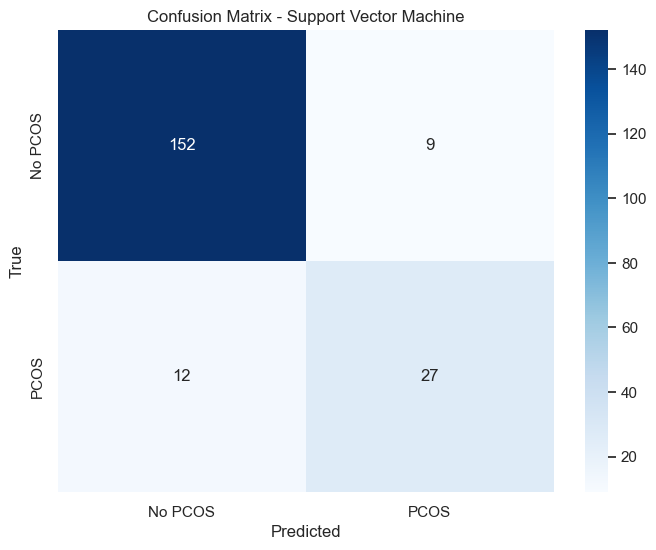

In [22]:
# Confusion Matrix SVM
Y_predi = SVM_model.predict(X_test)
print("Accuracy_SVM:", accuracy_score(Y_test, Y_predi))
plot_confusion_matrix(Y_test, Y_predi, "Support Vector Machine")

In [23]:
# LOGISTIC REGRESSION
LR_model = LogisticRegression(max_iter=10000, solver='saga')

# Perform Grid Search on selected feats for LR
par_LR = {'C': [0.1, 1, 10, 20]}
LR_search = GridSearchCV(estimator=LR_model, param_grid=par_LR, cv=5)
# Fitting Grid Search into the training data
LR_search.fit(X_train, Y_train)
print('Best Params for RF:', LR_search.best_params_)

Best Params for RF: {'C': 20}


In [24]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LR_model.fit(X_train_scaled, Y_train)

# Evaluation_LR
Y_predi = LR_model.predict(X_test_scaled)
print("Accuracy_LR:", accuracy_score(Y_test, Y_predi))
print("Confusion Matrix_LR:\n", confusion_matrix(Y_test, Y_predi))
print("Classification Report_LR:\n", classification_report(Y_test, Y_predi))

Accuracy_LR: 0.885
Confusion Matrix_LR:
 [[150  11]
 [ 12  27]]
Classification Report_LR:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       161
           1       0.71      0.69      0.70        39

    accuracy                           0.89       200
   macro avg       0.82      0.81      0.82       200
weighted avg       0.88      0.89      0.88       200



Accuracy_LR: 0.885


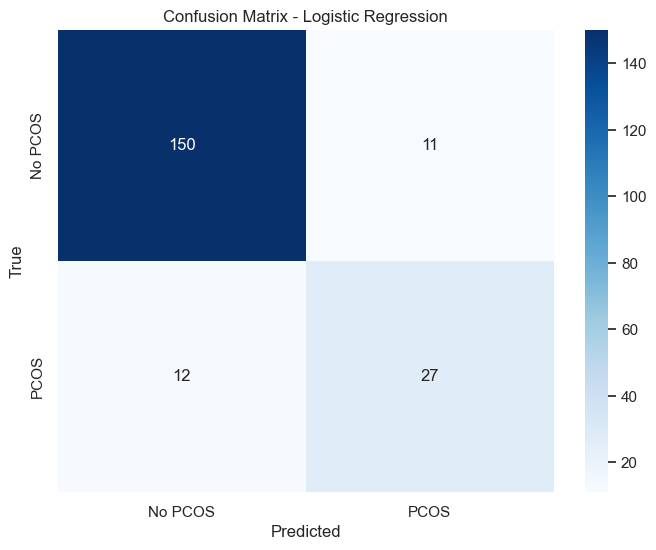

In [25]:
# Confusion Matrix
Y_predi = LR_model.predict(X_test_scaled)
print("Accuracy_LR:", accuracy_score(Y_test, Y_predi))
plot_confusion_matrix(Y_test, Y_predi, "Logistic Regression")

In [26]:
# Cross-Validation SCORES
RF_scores = cross_val_score(RF_model, X_train, Y_train, cv=10)
LR_scores = cross_val_score(LR_model, X_train, Y_train, cv=10)
SVM_scores = cross_val_score(SVM_model, X_train, Y_train, cv=10)

print(f"RF Cross-Validation Scores: {RF_scores}")
print(f"LR Cross-Validation Scores: {LR_scores}")
print(f"SVM Cross-Validation Scores: {SVM_scores}")
print(f"RF Mean Accuracy: {RF_scores.mean():.2f} ± {RF_scores.std():.2f}")
print(f"LR Mean Accuracy: {LR_scores.mean():.2f} ± {LR_scores.std():.2f}")
print(f"SVM Mean Accuracy: {SVM_scores.mean():.2f} ± {SVM_scores.std():.2f}")

RF Cross-Validation Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
LR Cross-Validation Scores: [0.875  0.8875 0.825  0.9375 0.9    0.9    0.8875 0.8875 0.9    0.8875]
SVM Cross-Validation Scores: [0.9    0.9375 0.85   0.95   0.9375 0.9625 0.9125 0.925  0.925  0.925 ]
RF Mean Accuracy: 1.00 ± 0.00
LR Mean Accuracy: 0.89 ± 0.03
SVM Mean Accuracy: 0.92 ± 0.03


In [27]:
# # Save model as a new file and selected features
joblib.dump((RF_model, sel_feats), 'PCOS_RF_MODEL.pkl')
joblib.dump((LR_model, sel_feats), 'PCOS_LR_MODEL.pkl')
joblib.dump((SVM_model, sel_feats), 'PCOS_SVM_MODEL.pkl')

['PCOS_SVM_MODEL.pkl']

In [32]:
# Input data for prediction
RF_model, sel_feats = joblib.load('PCOS_RF_MODEL.pkl')
LR_model, sel_feats = joblib.load('PCOS_LR_MODEL.pkl')
SVM_model, sel_feats = joblib.load('PCOS_SVM_MODEL.pkl')
input_values = [[24, 34.7, 1, 25.2]]  # Adjust based on selected features
input_df = pd.DataFrame(input_values, columns=sel_feats)

In [36]:
# Make a prediction
prediction = RF_model.predict(input_df)
if prediction == 0:
    print("PCOS Prediction (RF): PCOS is not present")
else:
    print("PCOS Prediction: PCOS is present")


PCOS Prediction (RF): PCOS is not present


In [34]:
# Make a prediction - LR
prediction = LR_model.predict(input_df)     

if prediction == 0:
    print("PCOS Prediction (LR): PCOS is not present")
else:
    print("PCOS Prediction (LR): PCOS is present")


PCOS Prediction (LR): PCOS is present


C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [35]:
# Make a prediction - SVM
prediction = SVM_model.predict(input_df)

if prediction == 0:
    print("PCOS Prediction (SVM): PCOS is not present")
else:
    print("PCOS Prediction (SVM): PCOS is present")


PCOS Prediction (SVM): PCOS is present
